In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 needed to register 3D projection
from matplotlib import cm

In [2]:

def build_grid_refined(steps: int = 96):
    """Create X, Y grids and corresponding Z values for Energy Reduction Potential."""

    # Baseline Energy Use per 15-minute period (kWh)
    e_per_15min = 14.811 + 14.811 + 5.183  # 34.805 kWh

    # X: Duration, represented by the number of 15-minute periods (1 to 96)
    # Use array of integers for clarity, then scale for calculation if desired
    # For a grid plot, we want fractional duration (0 to 1)
    # X_vals should ascend from 1/steps to 1.0 (1 period up to 96 periods)
    x_frac_vals = np.linspace(1.0 / steps, 1.0, steps)
    
    # Y: Percentage of Energy Reduction (0.01 to 1.0, or 1% to 100%)
    # Use array for fractional percentage (0.01 to 1.0)
    y_frac_vals = np.linspace(1.0 / steps, 1.0, steps)

    X, Y = np.meshgrid(x_frac_vals, y_frac_vals)
    
    # Z = Total Energy Reduction (kWh)
    # Total Reduction = (Duration in Periods) * (Energy per Period) * (Reduction Percentage)
    # Z = (X_frac * steps) * e_per_15min * Y_frac
    
    Z = (X * steps) * e_per_15min * Y
    
    return X, Y, Z


def plot_surface(X, Y, Z, outfile: str = "total_energy_reduction_surface.png"):
    """Plot and save the surface."""
    fig = plt.figure(figsize=(9, 6))
    ax = fig.add_subplot(111, projection="3d")

    surf = ax.plot_surface(X, Y, Z, cmap=cm.viridis, linewidth=0, antialiased=True, alpha=0.9)

    ax.set_xlabel("Energy Reduction")
    ax.set_ylabel("Duration per 24-hr")
    ax.set_zlabel("Total Energy Reduction")
    ax.set_title("Total Energy Reduction Surface")

    ax.set_xlim(1, 0)  # Keep the descending X axis intuitive.
    ax.view_init(elev=25, azim=-60)
    fig.colorbar(surf, shrink=0.6, aspect=12, label="Total Energy Reduction")
    plt.tight_layout()
    plt.savefig(outfile, dpi=200)
    return outfile


Saved surface plot to total_energy_reduction_surface.png


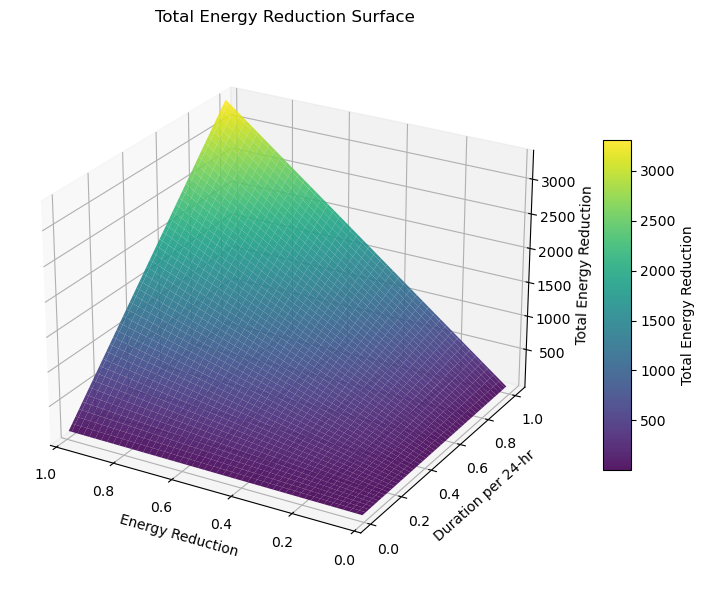

In [3]:
X, Y, Z = build_grid_refined()
outfile = plot_surface(X, Y, Z)
print(f"Saved surface plot to {outfile}")
